# Projeto Final — CP701TIN3 Processamento de Imagens Digitais

## Pipeline de Processamento de Imagens para Scanner de Documentos (CamScanner)

Este notebook implementa um pipeline de visão computacional **sem IA** para digitalizar documentos a partir de fotos, inspirado em aplicativos como o CamScanner.

**Referência de implementação:** [Python-Document-Scanner-OpenCV](https://github.com/ArashNasrEsfahani/Python-Document-Scanner-OpenCV) (Arash Nasr Esfahani, 2025).

### Etapas do pipeline
1. **Pré-processamento:** leitura da imagem e conversão para escala de cinza
2. **Processamento:** suavização (filtro Gaussiano) e detecção de bordas (Canny)
3. **Segmentação:** contornos e identificação do quadrilátero do documento
4. **Formatação:** correção de perspectiva e realce da imagem escaneada

> Coloque suas fotos na pasta `img/` (ex.: `image.png`). Opcional: defina `IMAGE_NAME = 'seuarquivo.jpg'` na célula abaixo; se deixar `None`, usa a primeira imagem encontrada em `img/`.


In [3]:
import os

# Backend sem GUI — evita travamento do kernel no macOS/Jupyter
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)

# Caminho da imagem (None = usa a primeira .jpg/.png/.jpeg em img/)
IMAGE_NAME = None  # ex.: 'image.png' ou 'documento.jpg'

PROJECT_DIR = Path('.').resolve()
IMG_DIR = PROJECT_DIR / 'img'
RESULT_DIR = PROJECT_DIR / 'resultado_final'
RESULT_DIR.mkdir(exist_ok=True)

_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
if IMAGE_NAME:
    IMAGE_PATH = IMG_DIR / IMAGE_NAME
else:
    imagens = sorted(
        p for p in IMG_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in _EXT
    )
    IMAGE_PATH = imagens[0] if imagens else IMG_DIR / 'documento.jpg'

print(f'Imagem de entrada: {IMAGE_PATH}')



Imagem de entrada: /Users/joaogabriellopesaguiar/Documents/Processamento de Imagens/Projeto_Final/img/image.png


## 1. Carregar e visualizar a imagem original

Equivalente à leitura de arquivos visto na **Aula 1** (`cv.imread`).


Dimensões (linhas, colunas, canais): (800, 600, 3)


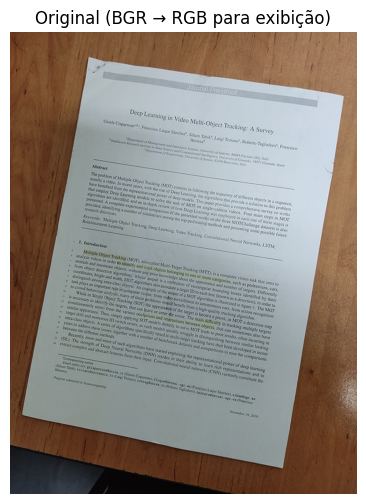

In [4]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {IMAGE_PATH}\n'
        f'Coloque uma foto em {IMG_DIR}/ e atualize IMAGE_PATH.'
    )

original = cv.imread(str(IMAGE_PATH))
if original is None:
    raise ValueError(f'Não foi possível ler a imagem: {IMAGE_PATH}')

print('Dimensões (linhas, colunas, canais):', original.shape)

plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Original (BGR → RGB para exibição)')
plt.axis('off')
plt.show()



## 2. Pré-processamento — Escala de cinza

Conversão **BGR → GRAY** com `cv.cvtColor` (**Aula 1**). Reduz de 3 canais para 1, facilitando filtros e limiarização.


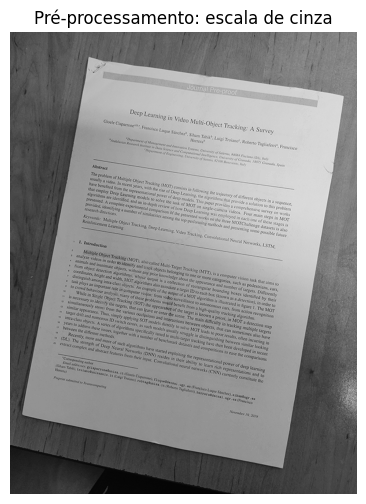

In [5]:
def to_grayscale(im):
    return cv.cvtColor(im, cv.COLOR_BGR2GRAY)

grayscale = to_grayscale(original)

plt.imshow(grayscale, cmap='gray')
plt.title('Pré-processamento: escala de cinza')
plt.axis('off')
plt.show()



## 3. Processamento — Filtro Gaussiano

Suavização com kernel **3×3** para reduzir ruído antes da detecção de bordas (**Aulas 7 e 8** — convolução passa-baixa).


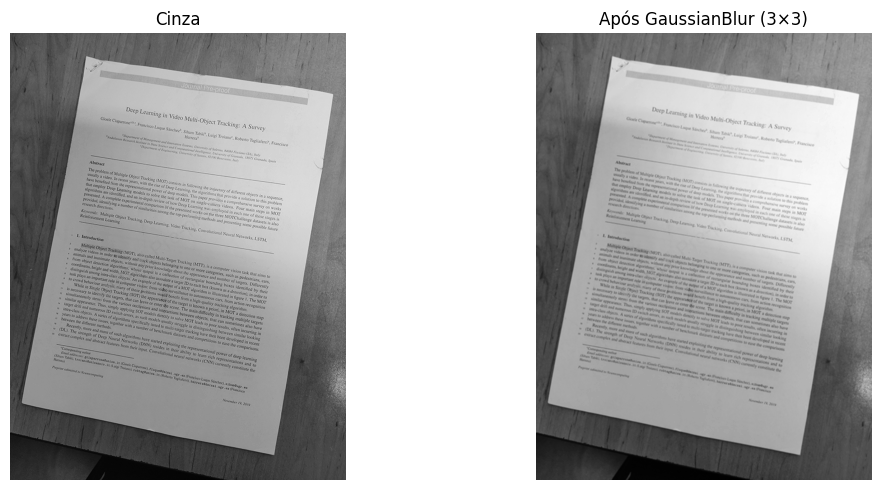

In [6]:
def blur(im, ksize=(3, 3)):
    return cv.GaussianBlur(im, ksize, 0)

blurred = blur(grayscale)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(grayscale, cmap='gray')
ax[0].set_title('Cinza')
ax[0].axis('off')
ax[1].imshow(blurred, cmap='gray')
ax[1].set_title('Após GaussianBlur (3×3)')
ax[1].axis('off')
plt.tight_layout()
plt.show()



## 4. Processamento — Detecção de bordas (Canny)

O detector **Canny** usa dois limiares (**50** e **150**): pixels com gradiente forte viram borda; valores intermediários são conectados por histerese. Relacionado aos operadores de gradiente da **Aula 9** (Sobel, Prewitt).


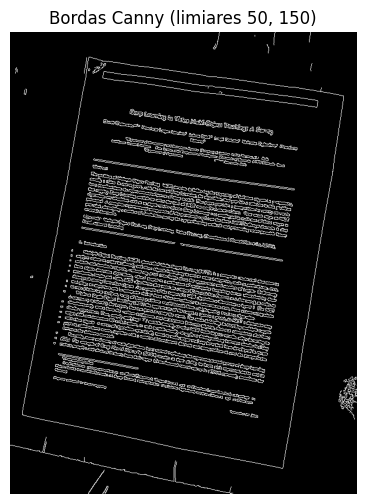

In [7]:
def to_edges(im, low=50, high=150):
    return cv.Canny(im, low, high)

edges = to_edges(blurred)

plt.imshow(edges, cmap='gray')
plt.title(f'Bordas Canny (limiares {50}, {150})')
plt.axis('off')
plt.show()



## 5. Segmentação — Contornos e quatro cantos do documento

- `cv.findContours` encontra formas fechadas no mapa de bordas
- Ordenação por área (`cv.contourArea`)
- `cv.approxPolyDP` simplifica o contorno até um quadrilátero (4 vértices)

Documentação: [Contours — OpenCV](https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html)


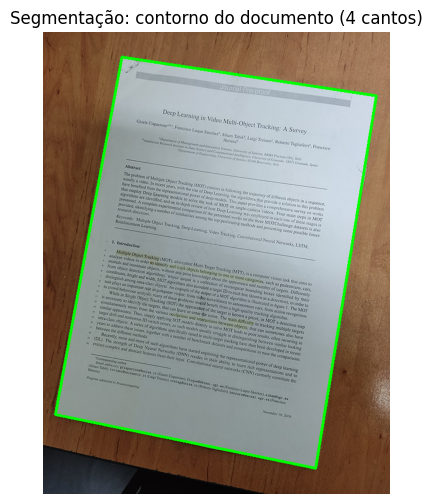

In [8]:
def reorder(vertices):
    """Ordena pontos: topo-esq, topo-dir, baixo-dir, baixo-esq (exigido pelo OpenCV)."""
    reordered = np.zeros_like(vertices, dtype=np.float32)
    add = vertices.sum(axis=1)
    reordered[0] = vertices[np.argmin(add)]
    reordered[2] = vertices[np.argmax(add)]
    diff = np.diff(vertices, axis=1)
    reordered[1] = vertices[np.argmin(diff)]
    reordered[3] = vertices[np.argmax(diff)]
    return reordered


def find_vertices(edge_map, original_shape):
    contours, _ = cv.findContours(
        edge_map.copy(), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE
    )
    contours = sorted(contours, key=cv.contourArea, reverse=True)[:5]

    vertices = None
    for cnt in contours:
        epsilon = 0.02 * cv.arcLength(cnt, True)
        approx = cv.approxPolyDP(cnt, epsilon, True)
        if len(approx) == 4:
            vertices = approx.reshape(4, 2)
            break

    if vertices is None:
        h, w = original_shape[:2]
        vertices = np.array(
            [[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32
        )
        print('Aviso: quadrilátero não encontrado; usando cantos da imagem inteira.')

    return reorder(vertices.astype(np.float32))

vertices = find_vertices(edges, original.shape)

overlay = original.copy()
for i in range(4):
    pt1 = tuple(vertices[i].astype(int))
    pt2 = tuple(vertices[(i + 1) % 4].astype(int))
    cv.line(overlay, pt1, pt2, (0, 255, 0), 3)

plt.imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
plt.title('Segmentação: contorno do documento (4 cantos)')
plt.axis('off')
plt.show()



## 6. Formatação — Transformação de perspectiva

Generalização das transformações geométricas das **Aulas 3–5** (`warpAffine` → `warpPerspective`):

- `cv.getPerspectiveTransform`: matriz 3×3 a partir de 4 pares de pontos
- `cv.warpPerspective`: vista top-down (birds-eye view)

Tutorial: [Geometric Transformations — OpenCV](https://docs.opencv.org/4.x/da/d6e/tutorial_py_geometric_transformations.html)


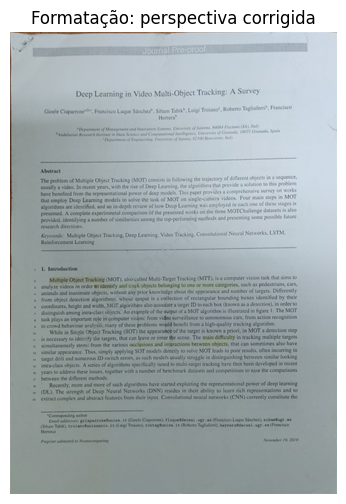

In [9]:
def crop_out(im, vertices, width=600, height=850):
    target = np.array(
        [[0, 0], [width, 0], [width, height], [0, height]],
        dtype=np.float32,
    )
    transform = cv.getPerspectiveTransform(vertices, target)
    return cv.warpPerspective(im, transform, (width, height))

warped = crop_out(original, vertices)

plt.imshow(cv.cvtColor(warped, cv.COLOR_BGR2RGB))
plt.title('Formatação: perspectiva corrigida')
plt.axis('off')
plt.show()



## 7. Formatação — Realce da imagem escaneada

Pós-processamento baseado no repositório de referência: correção gamma (`cv.LUT`, **Aula 6**), CLAHE no canal L do espaço LAB e nitidez controlada.


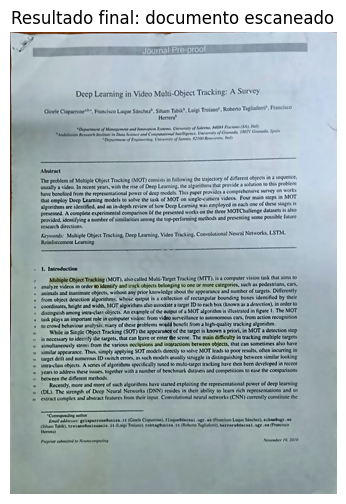

In [10]:
def enhance(im):
    gamma = 1.1
    inv_gamma = 1.0 / gamma
    table = np.array([
        ((i / 255.0) ** inv_gamma) * 255 for i in np.arange(256)
    ]).astype('uint8')
    corrected = cv.LUT(im, table)

    lab = cv.cvtColor(corrected, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(12, 12))
    l = clahe.apply(l)
    enhanced = cv.cvtColor(cv.merge([l, a, b]), cv.COLOR_LAB2BGR)

    hsv = cv.cvtColor(enhanced, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    s_clean = cv.bilateralFilter(s, 9, 75, 75)
    s = cv.addWeighted(s, 1.2, s_clean, 0.3, 0)
    s = np.clip(s, 20, 230).astype(np.uint8)
    enhanced = cv.cvtColor(cv.merge([h, s, v]), cv.COLOR_HSV2BGR)

    blurred = cv.GaussianBlur(enhanced, (0, 0), 2.0)
    sharpened = cv.addWeighted(enhanced, 1.5, blurred, -0.5, 0)
    return cv.bilateralFilter(sharpened, 9, 75, 75)

scanned = enhance(warped)

plt.imshow(cv.cvtColor(scanned, cv.COLOR_BGR2RGB))
plt.title('Resultado final: documento escaneado')
plt.axis('off')
plt.show()



## 8. Pipeline completo e comparação

Função `scan()` executa todas as etapas em sequência (como no notebook de referência).


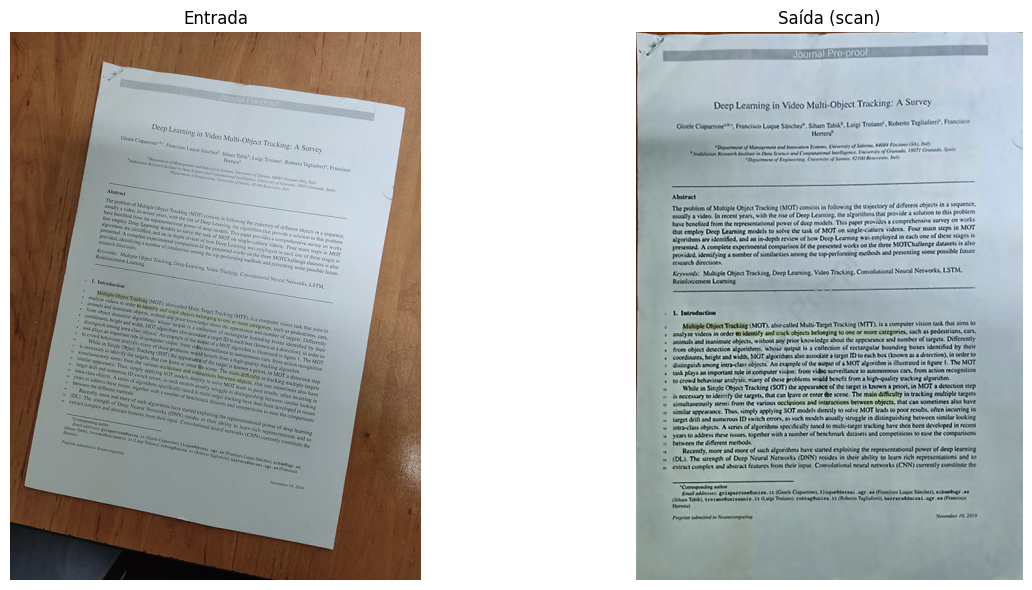

Resultado salvo em: /Users/joaogabriellopesaguiar/Documents/Processamento de Imagens/Projeto_Final/resultado_final/resultado_scan.jpg


In [11]:
def scan(im):
    gray = to_grayscale(im)
    blurred = blur(gray)
    edge_map = to_edges(blurred)
    verts = find_vertices(edge_map, im.shape)
    cropped = crop_out(im, verts)
    return enhance(cropped), edge_map, verts

resultado, _, _ = scan(original)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
axes[0].set_title('Entrada')
axes[0].axis('off')
axes[1].imshow(cv.cvtColor(resultado, cv.COLOR_BGR2RGB))
axes[1].set_title('Saída (scan)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

out_path = RESULT_DIR / 'resultado_scan.jpg'
cv.imwrite(str(out_path), resultado)
print(f'Resultado salvo em: {out_path}')

